# GTF/GFF Benchmark Example

End-to-end evaluation of a gene predictor (Augustus) against GENCODE ground truth, starting from annotation files.

In [1]:
from pathlib import Path
from dna_segmentation_benchmark import (
    LabelConfig, EvalMetrics, benchmark_from_gff, compare_multiple_predictions,
)

label_config = LabelConfig(
    labels={0: "CDS", 8: "NONCODING"},
    background_label=8,
    coding_label=0,
)

metrics = [
    EvalMetrics.INDEL,
    EvalMetrics.REGION_DISCOVERY,
    EvalMetrics.BOUNDARY_EXACTNESS,
    EvalMetrics.NUCLEOTIDE_CLASSIFICATION,
]

`benchmark_from_gff` wraps the full pipeline: parse files, map transcripts, build arrays, compute metrics.

In [2]:
results = benchmark_from_gff(
    gt_path="../example_data/augustus_test/filtered.gtf",
    pred_paths={"augustus": "../example_data/augustus_test/chr2_augustus_pred.gff"},
    label_config=label_config,
    classes=[0],
    metrics=metrics,
    exclude_features=["gene"],
)

Running benchmark: 100%|██████████| 2343/2343 [00:07<00:00, 320.98it/s]


Generate all plots. The `results` dict is keyed by predictor name — pass it directly to the plotting orchestrator.

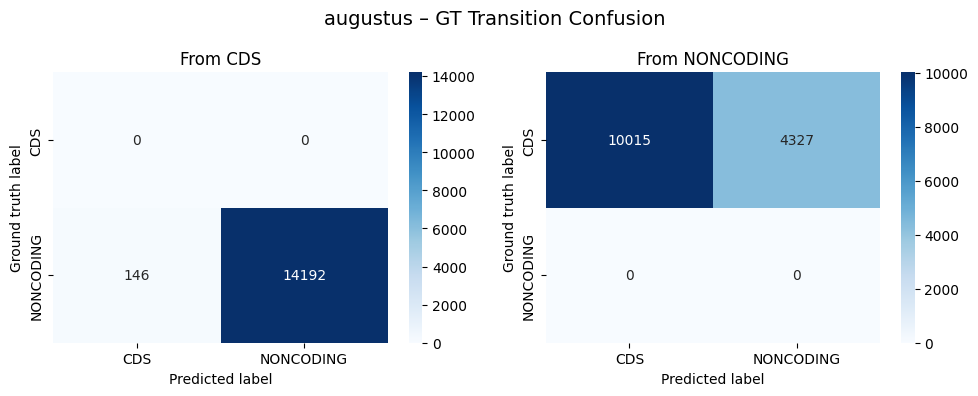

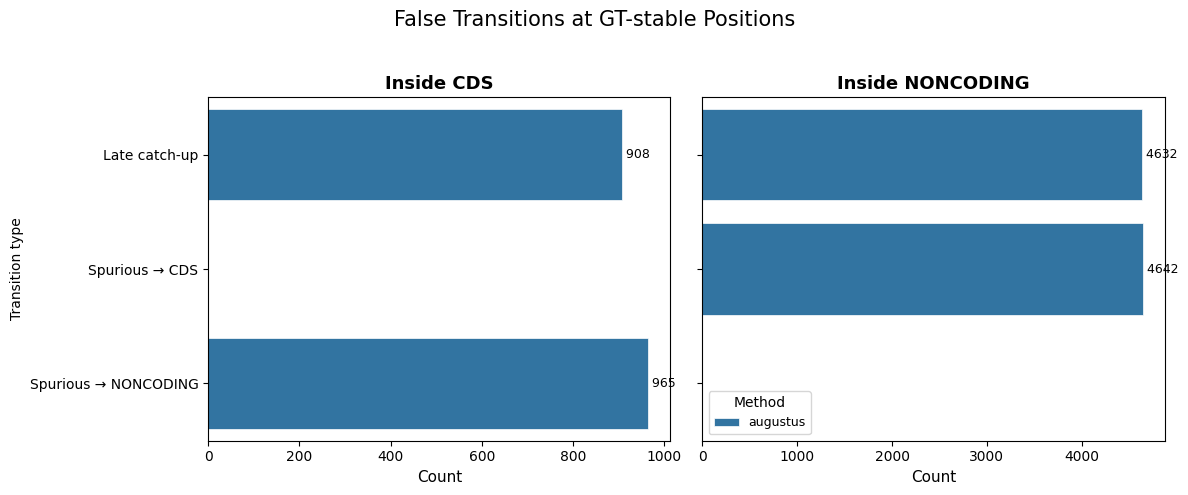

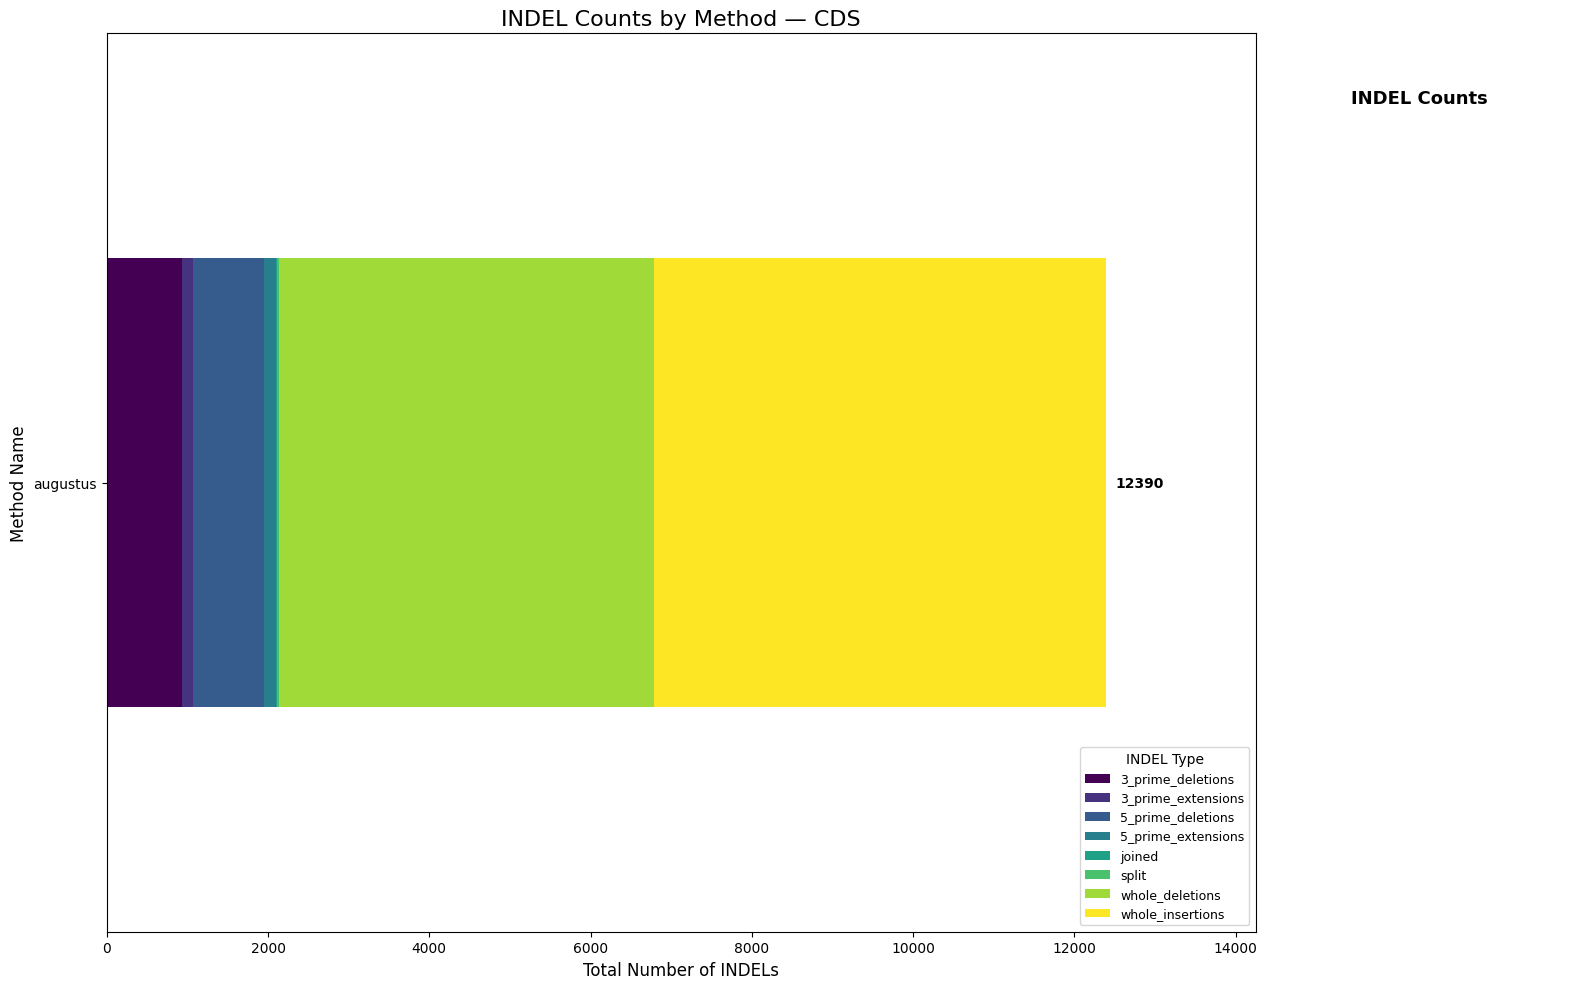

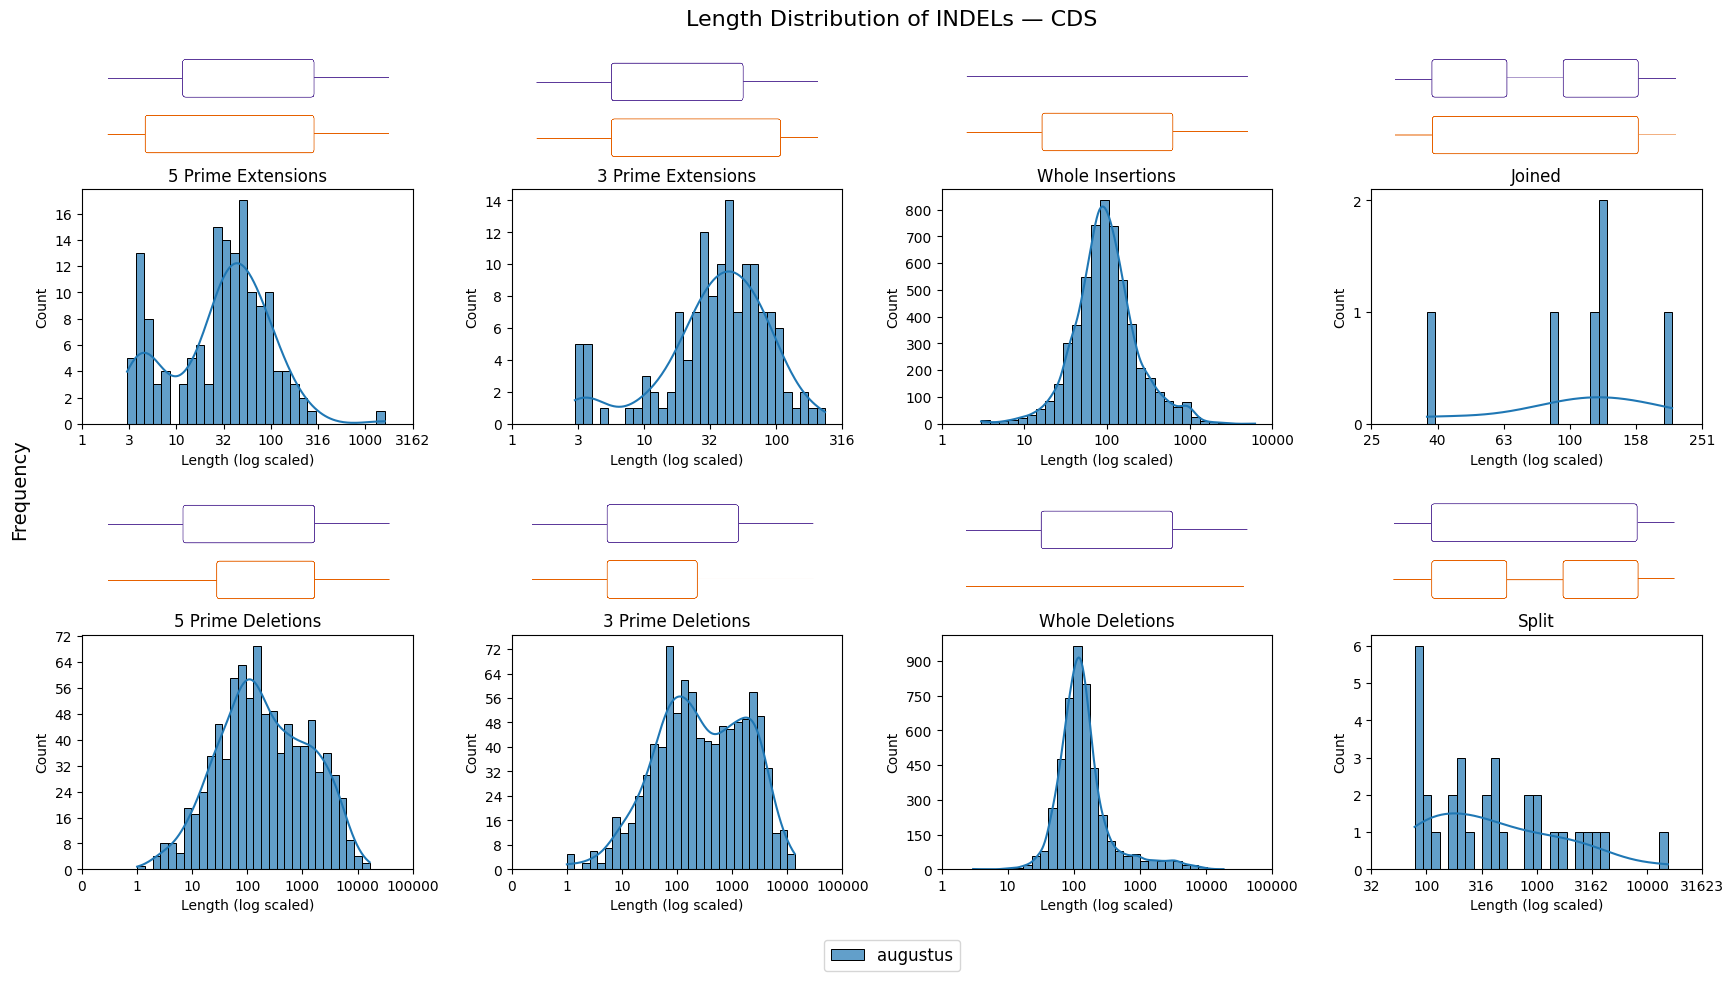

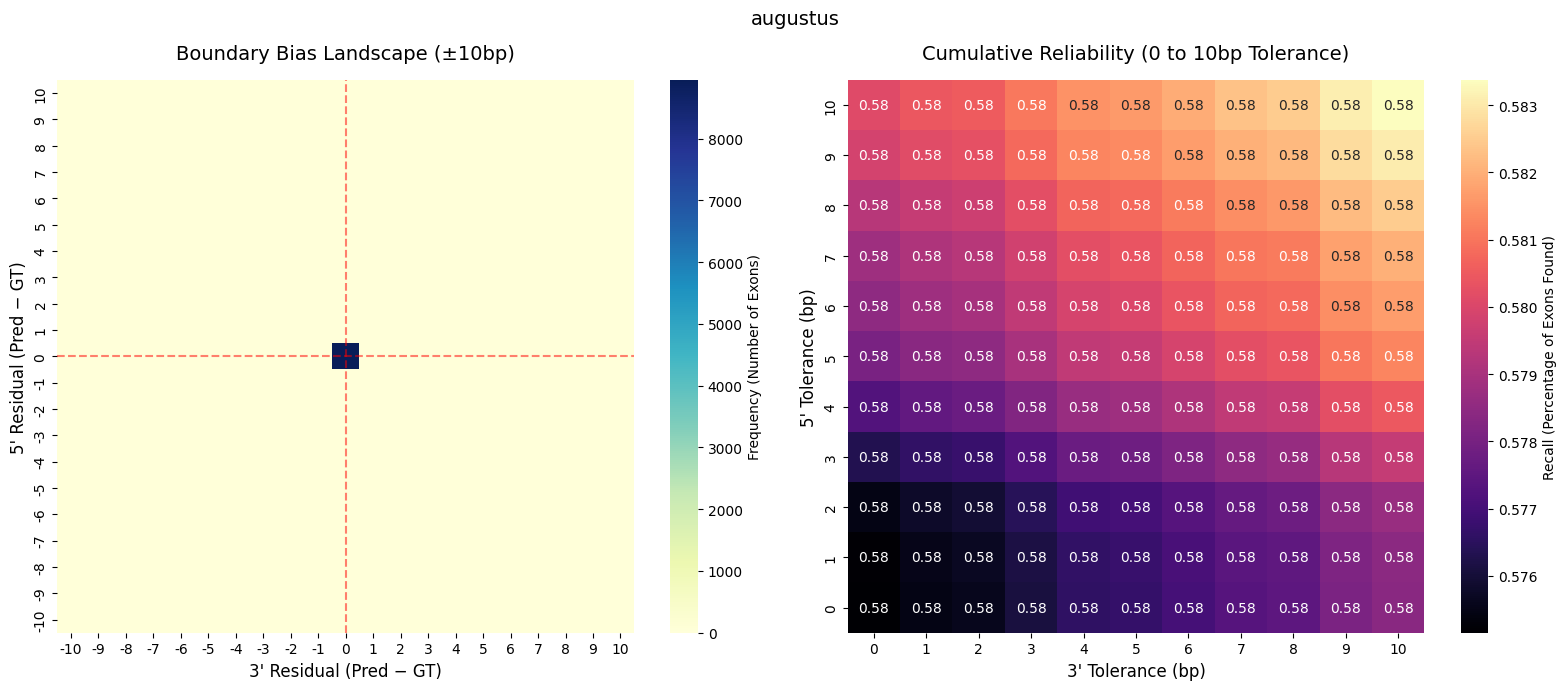

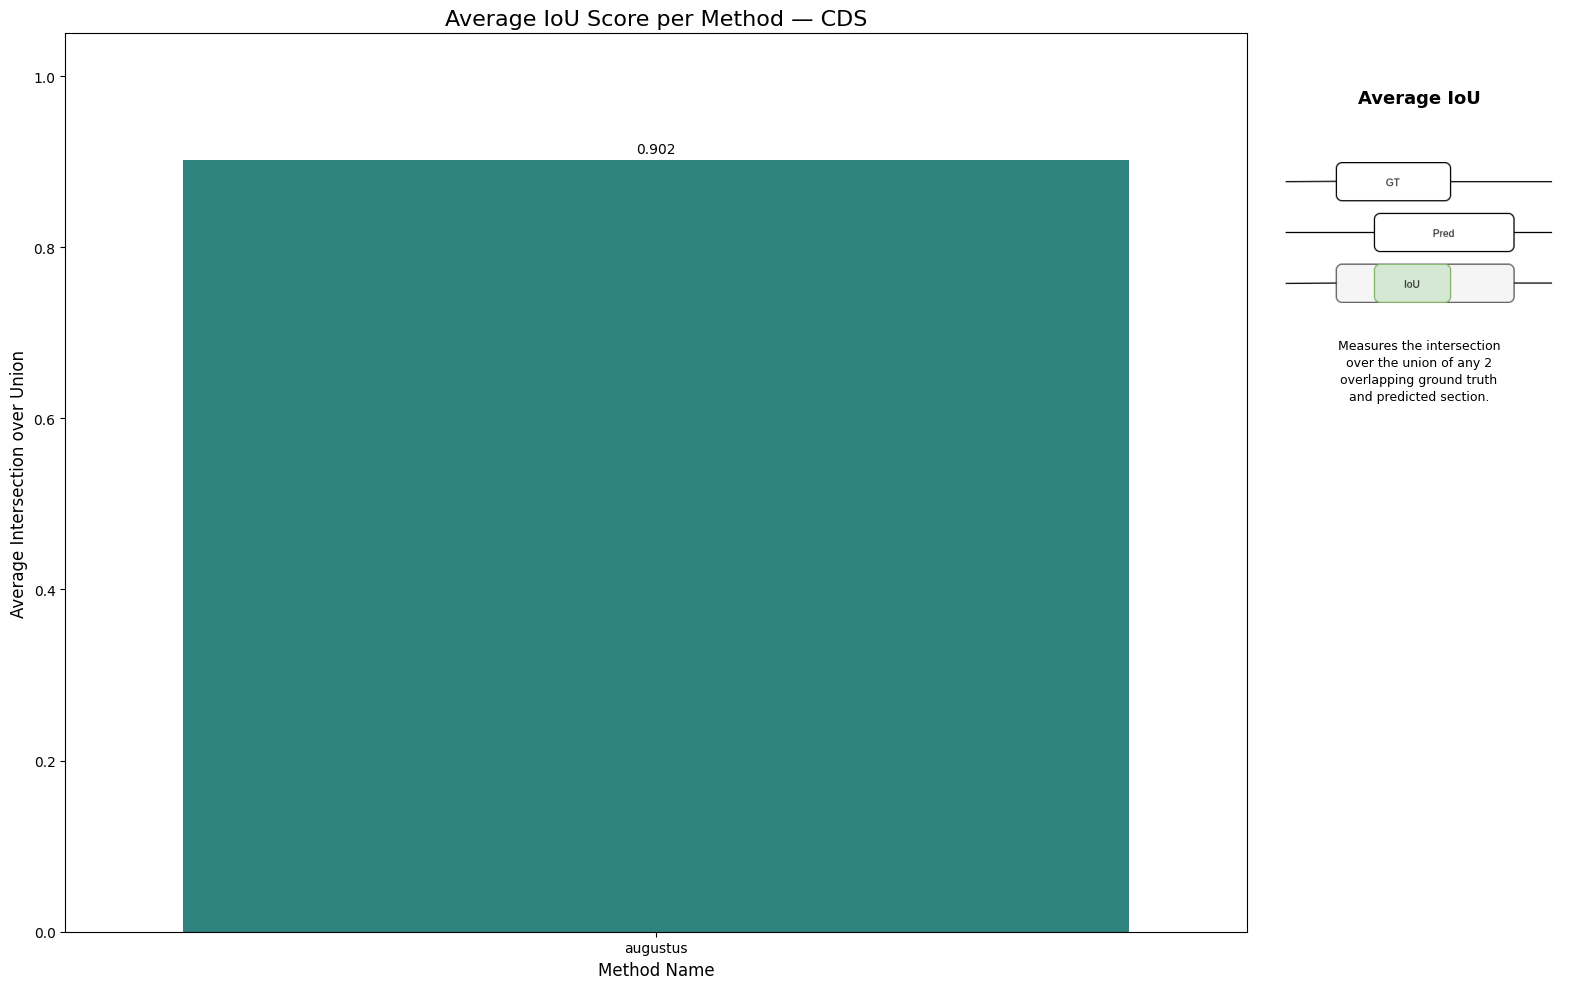

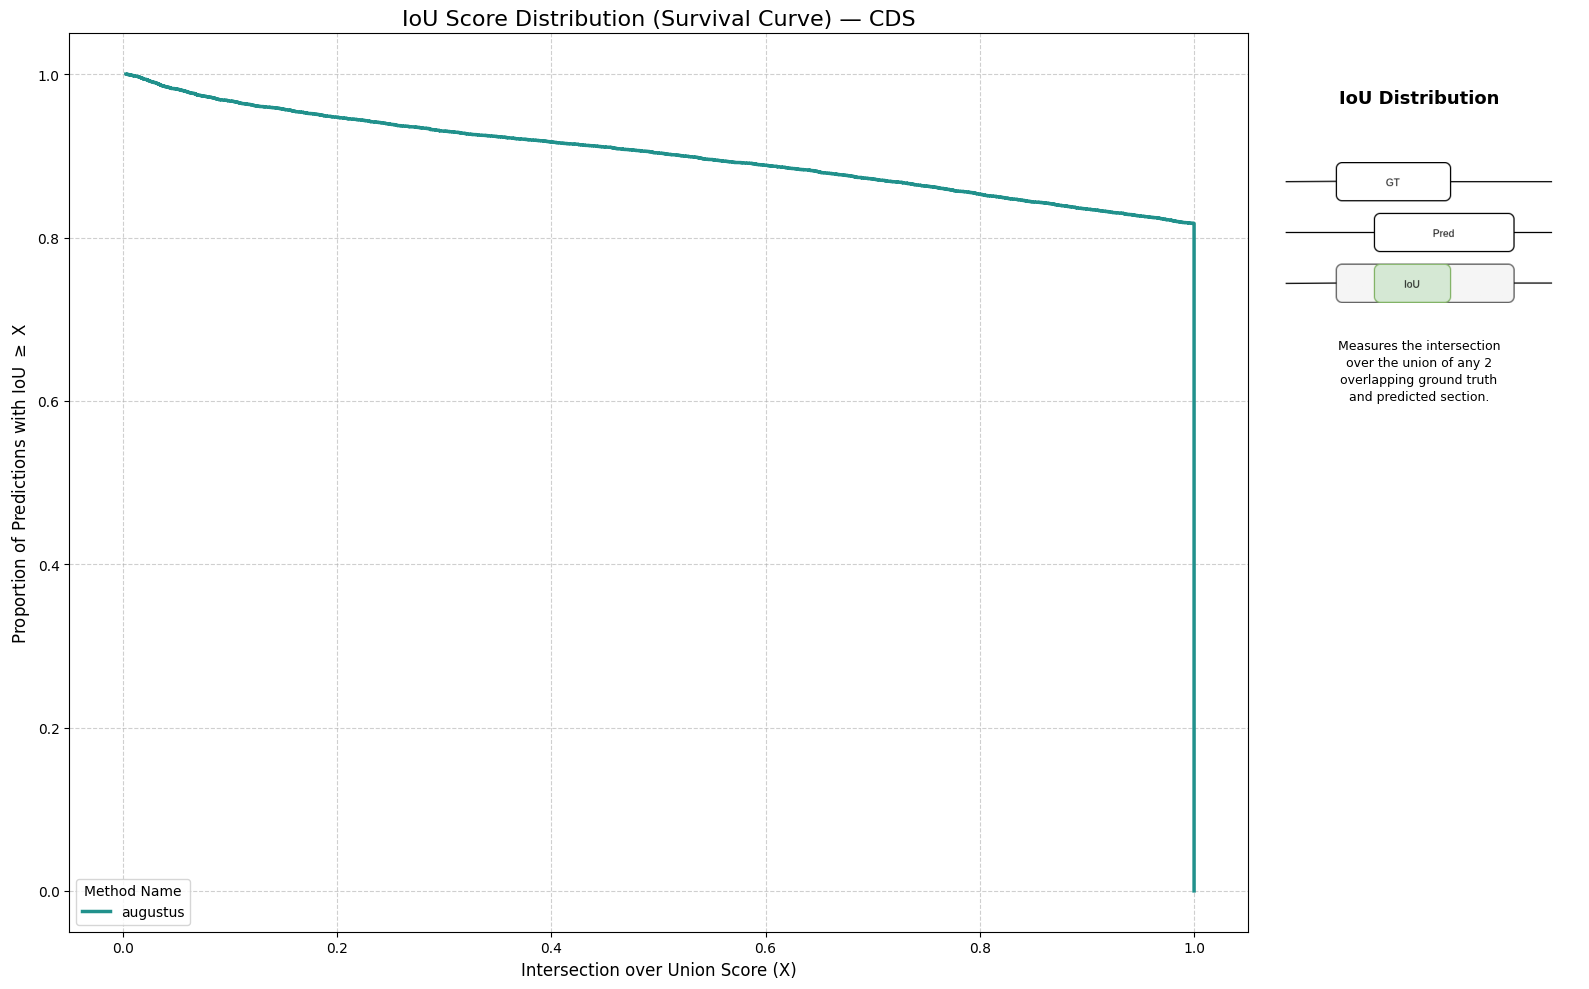

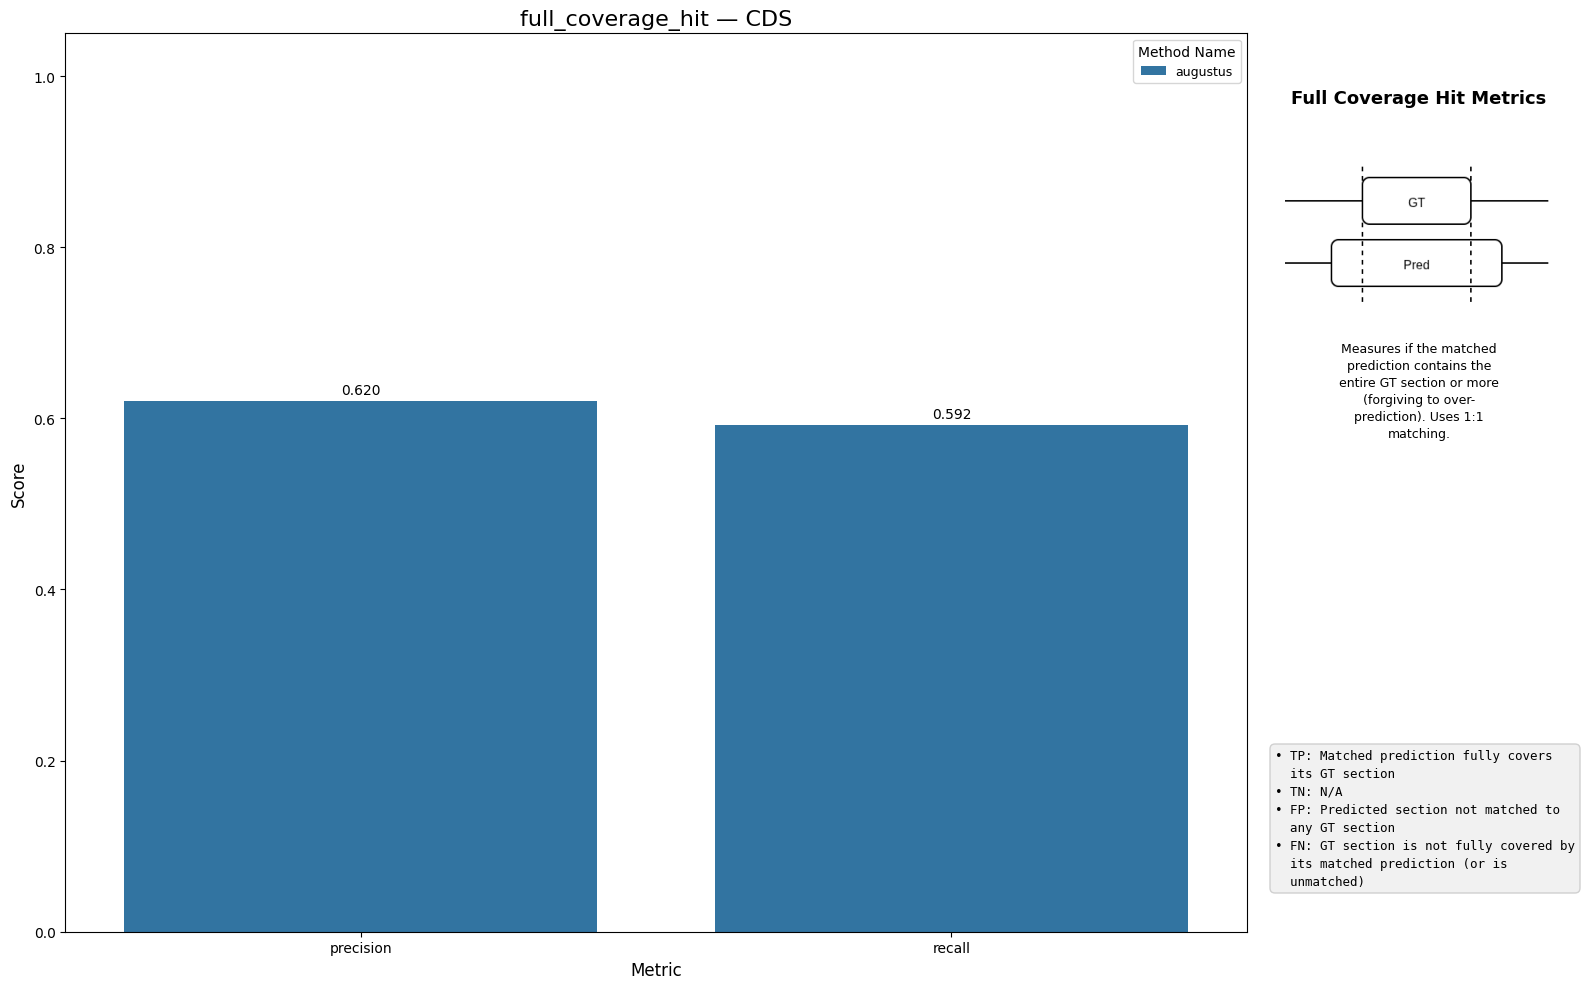

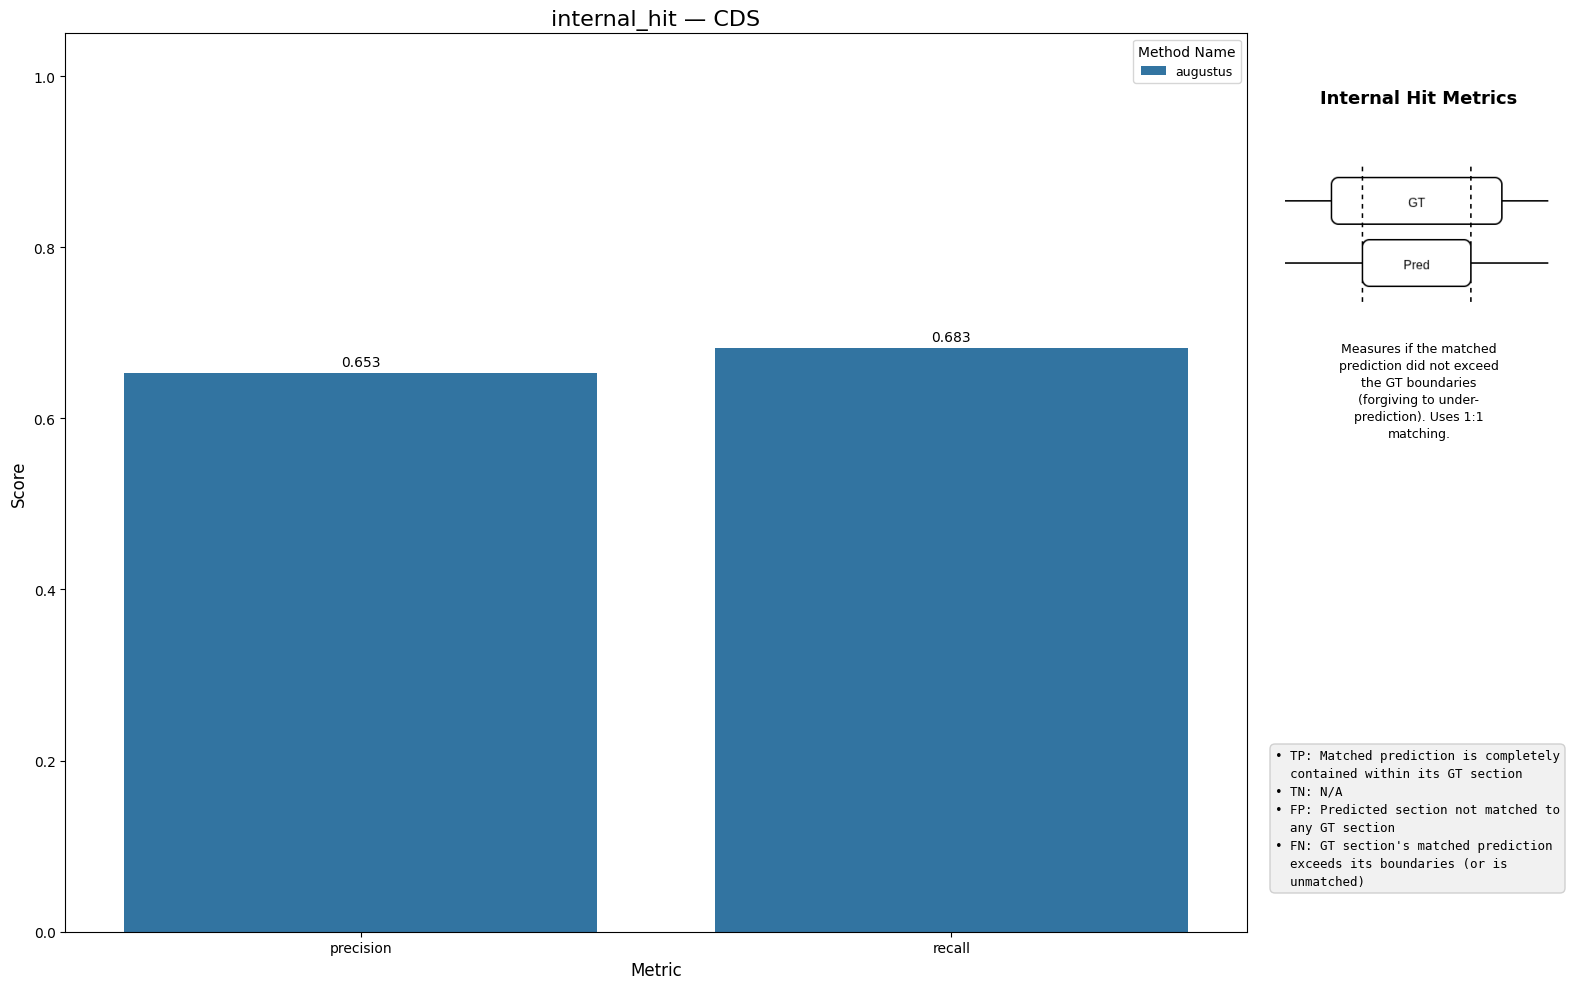

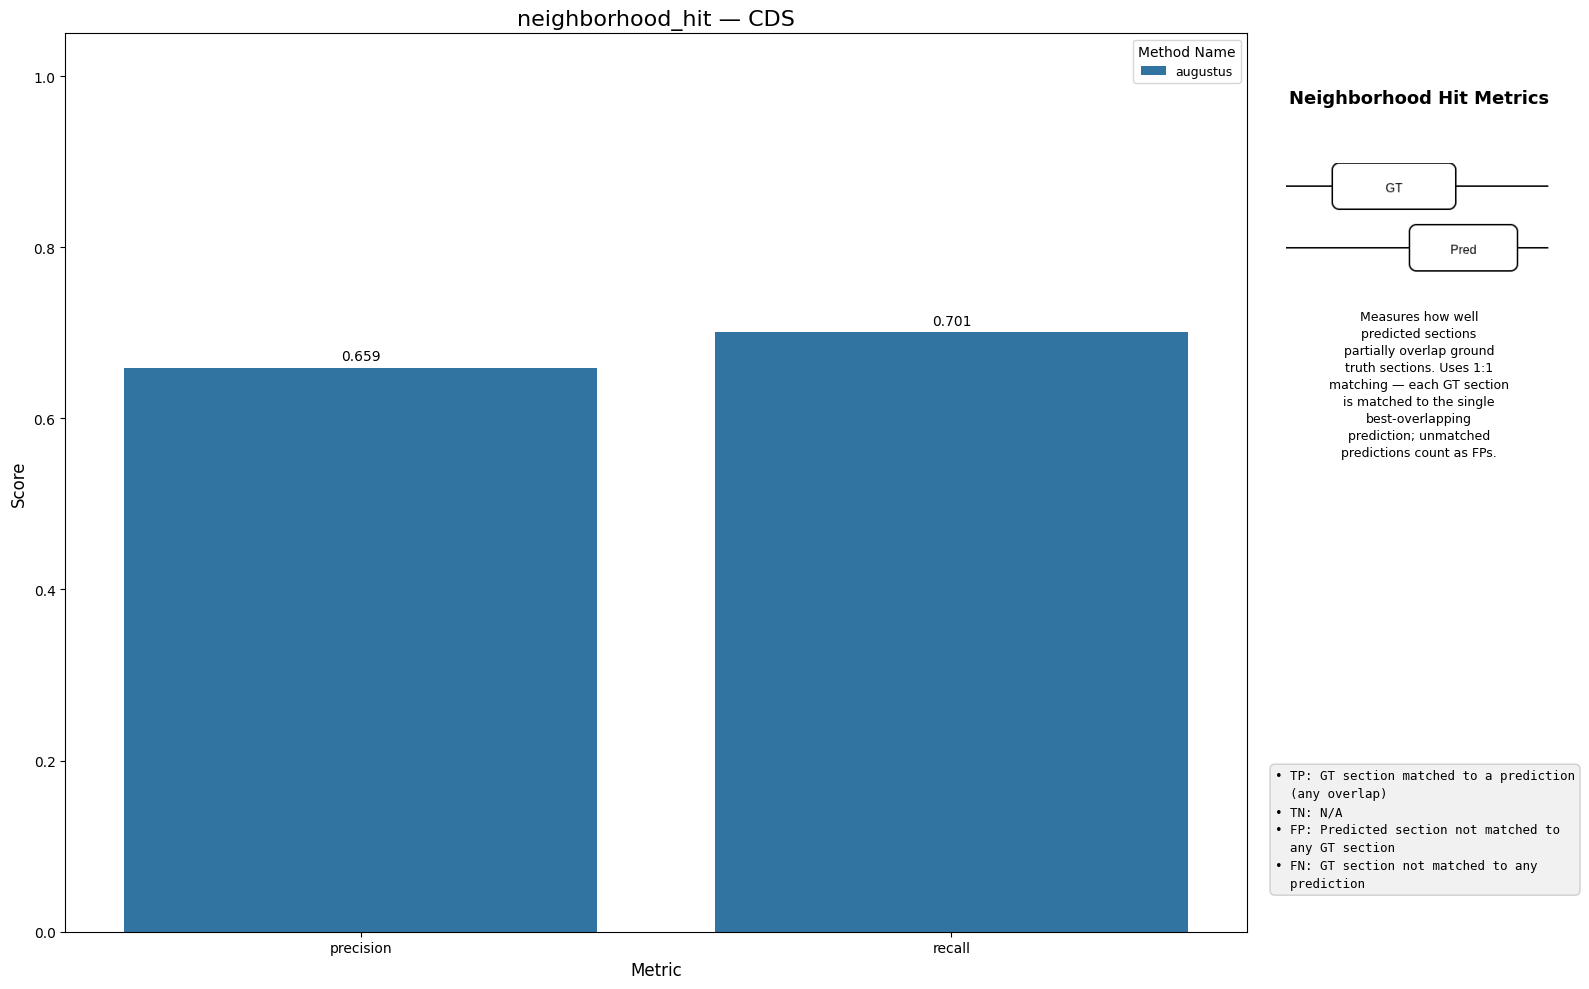

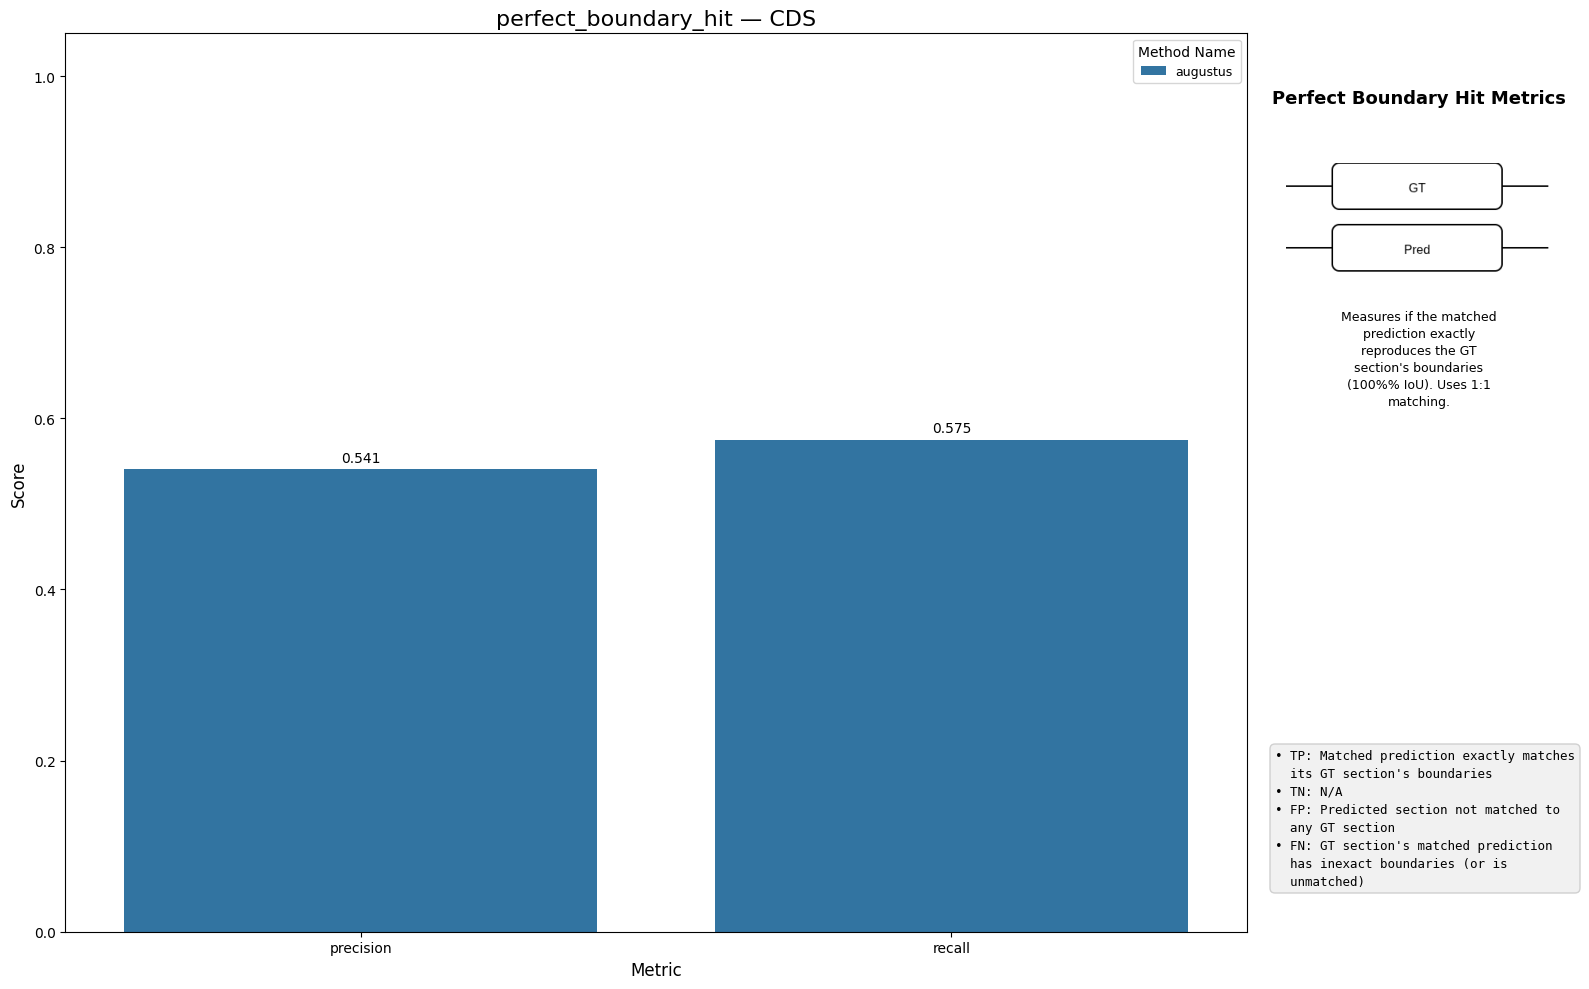

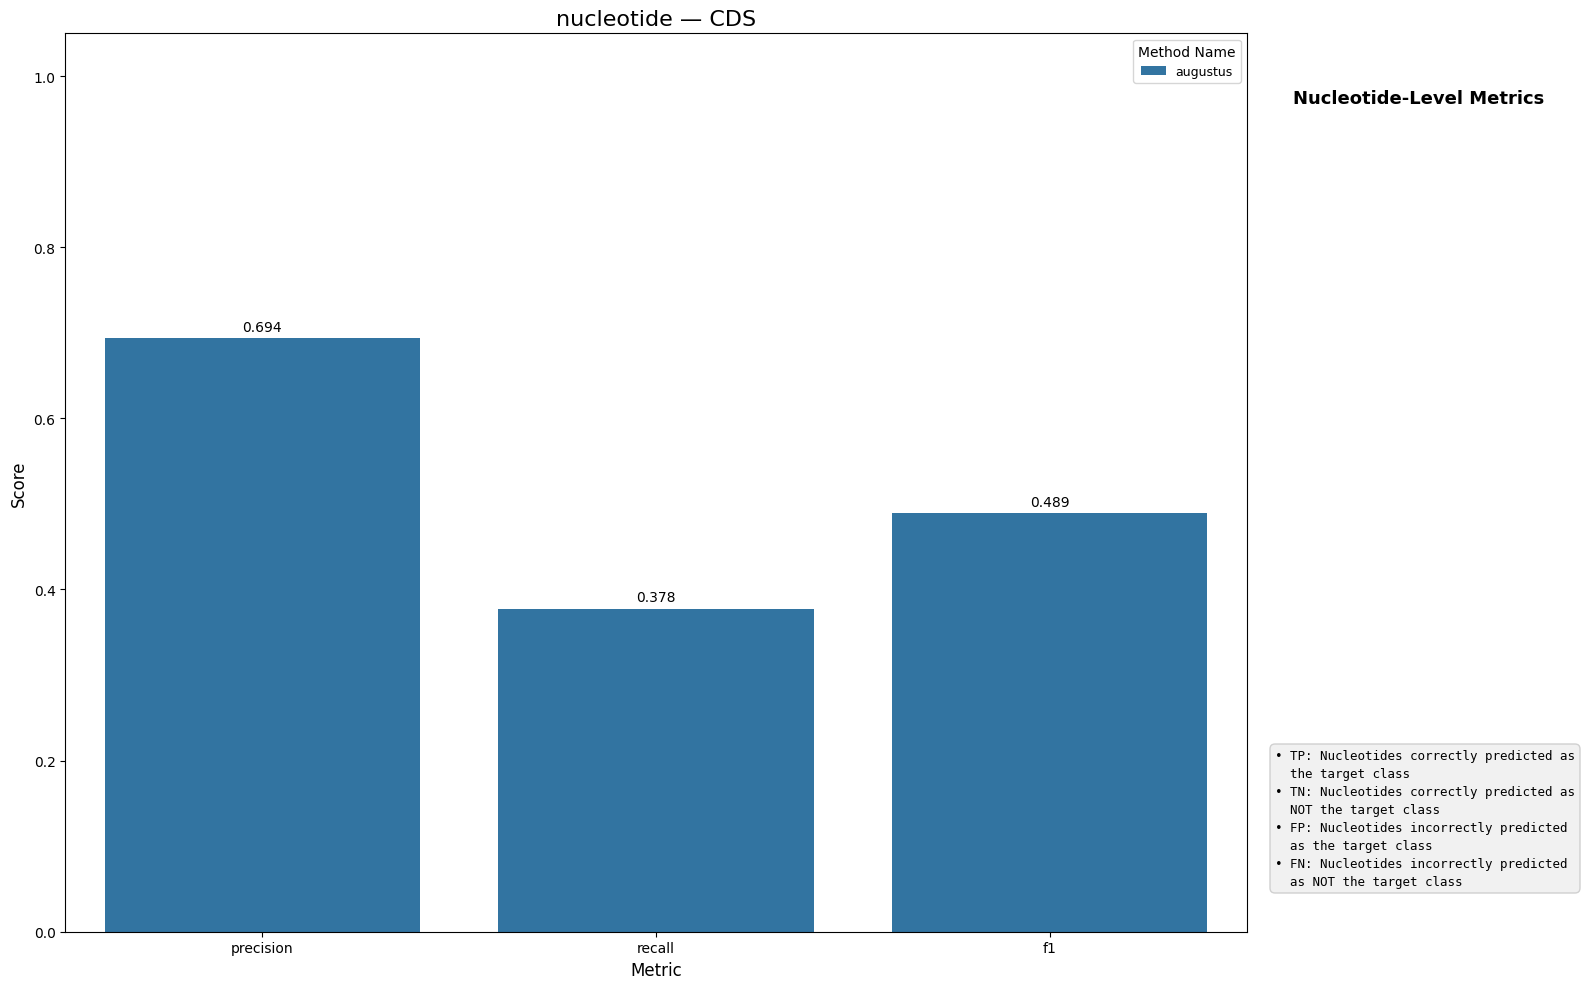

In [3]:
figures = compare_multiple_predictions(
    per_method_benchmark_res=results,
    label_config=label_config,
    classes=[0],
    metrics_to_eval=metrics,
    output_dir=Path("../plots/gtf_example"),
)

import matplotlib.pyplot as plt
for fig in figures.values():
    plt.show()